In [1]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
plt.rcParams["figure.figsize"] = (24,18)

from cv_utils import *
import houghlines_process as hp

(1440, 2560, 3)


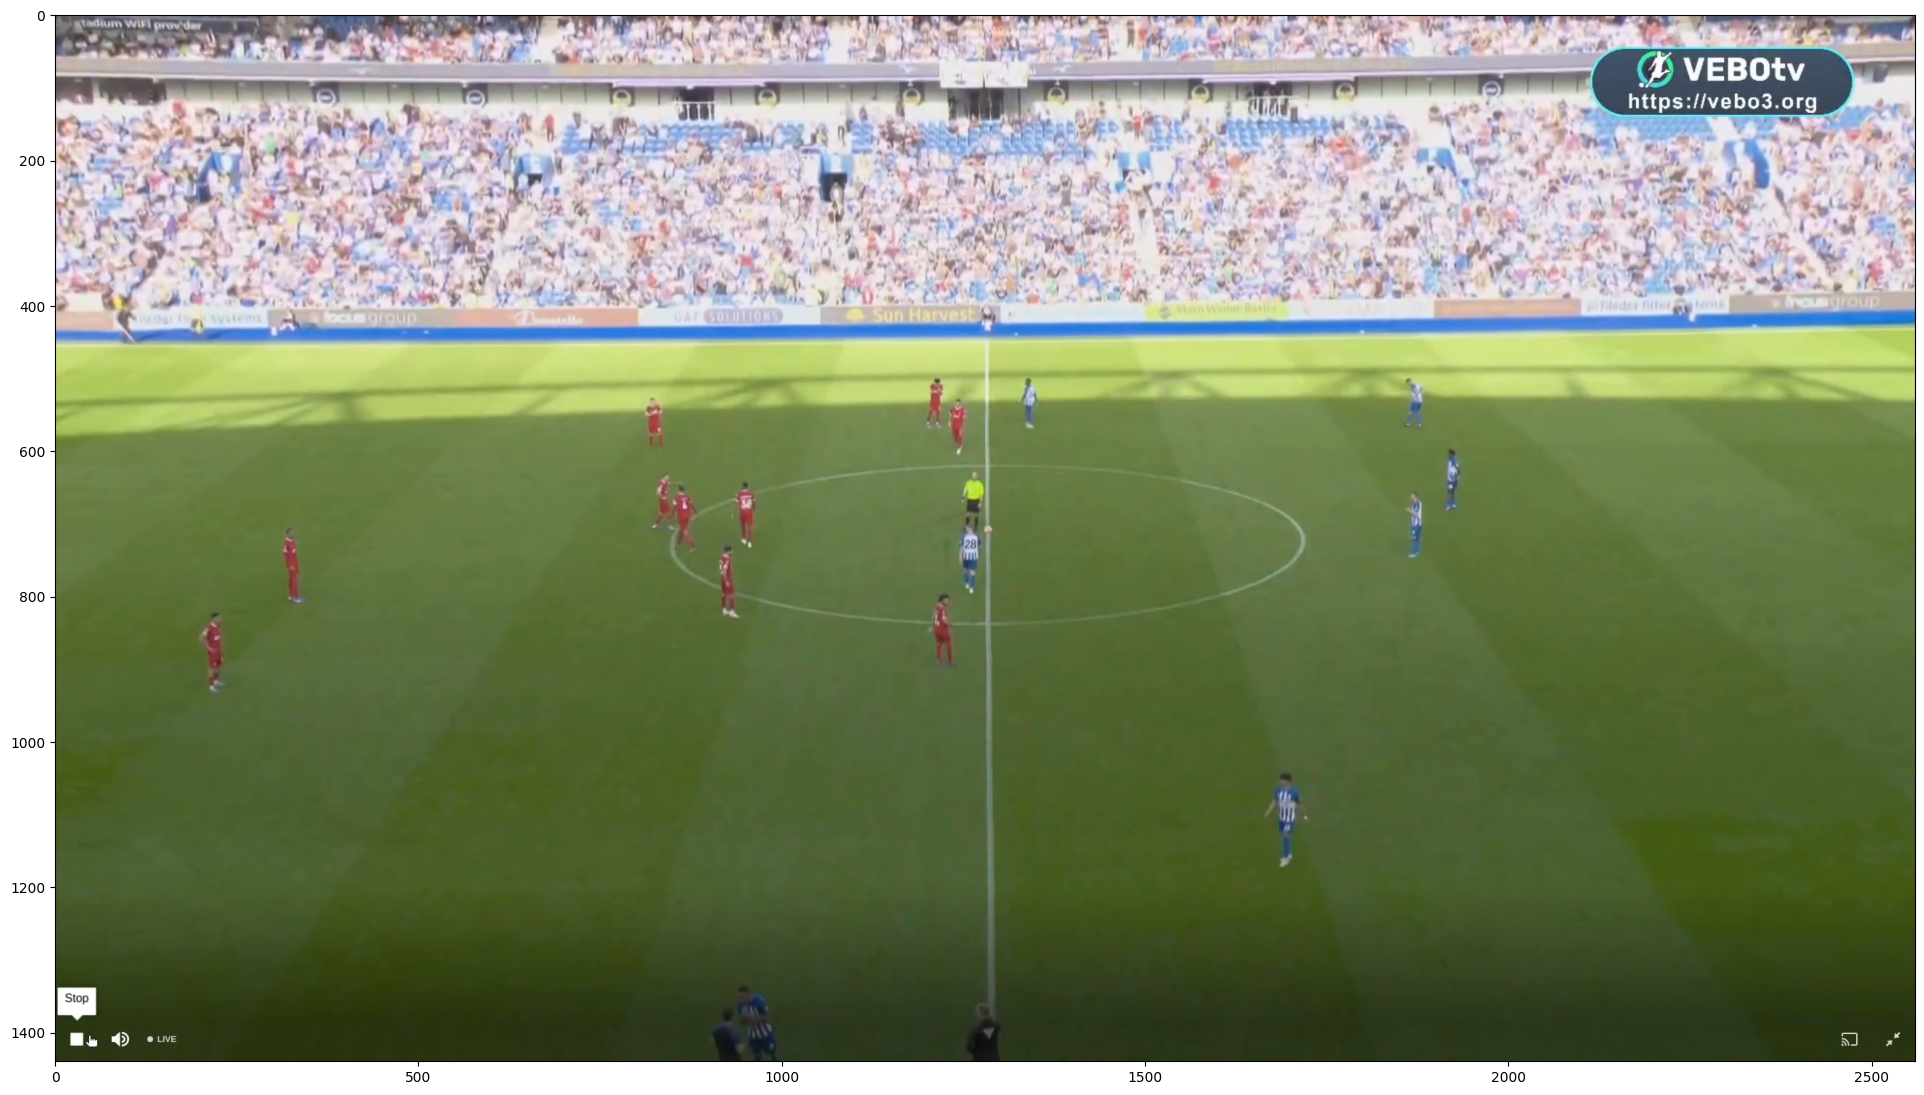

In [2]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
vid_name = 'Liv-BHA 2nd half'
images_path = os.path.join(data_path, 'images' + '/' + vid_name)

image_path = os.path.join(images_path, os.listdir(images_path)[0])
rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)
print(rgb_image.shape)

plt.figure()
plt.imshow(rgb_image[:,:,::-1])

[  0   1   4   5   7   9  10  11  14  15  22  28  29  30  34  35  36  37  38  39  40  41  42  43  44  45  46 104 105 106 107 108 110 112 113 115 116 117 118 119 120 121 122 126 128 129 130 134 135 137 138 139 144 145 147 148 149 150 152 155 157 158 159 160 161 162 163 165 166 167 168 169 170 171 173 175 178 179]


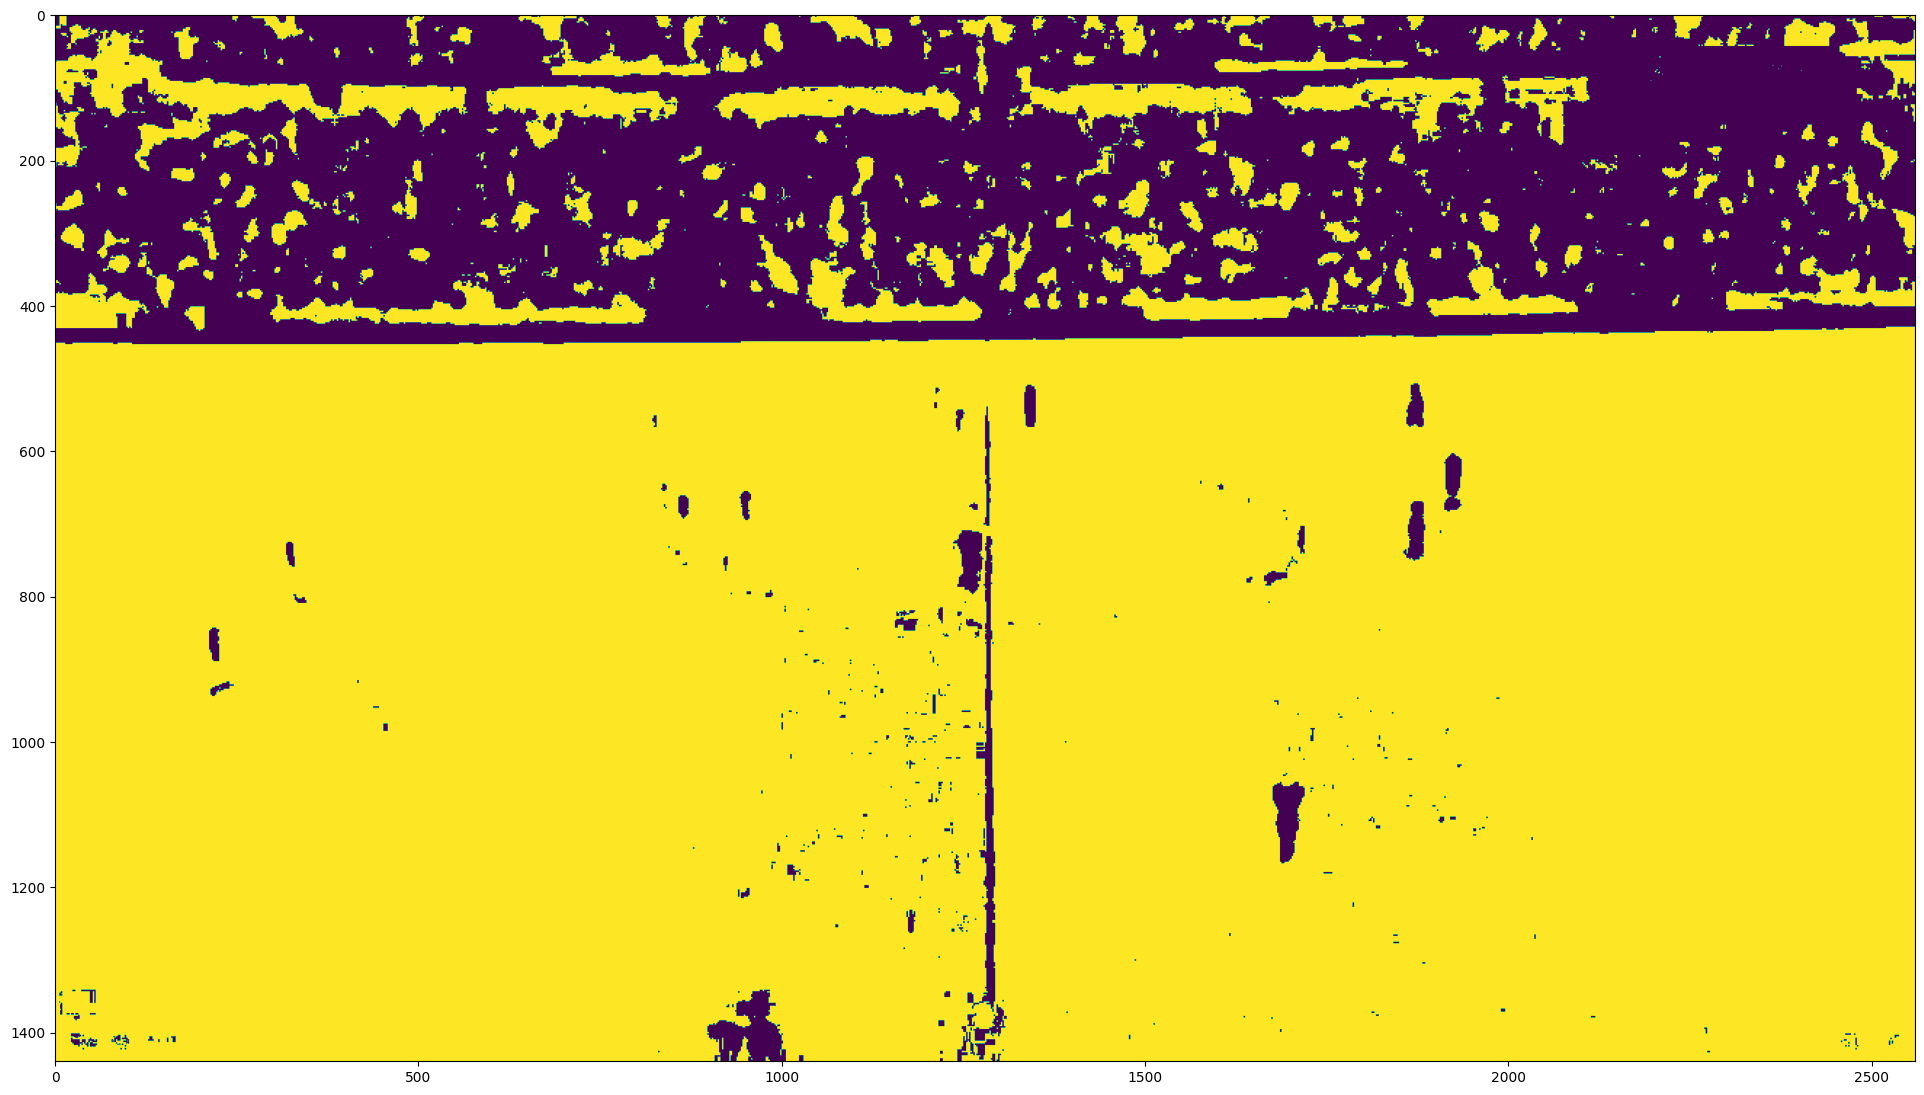

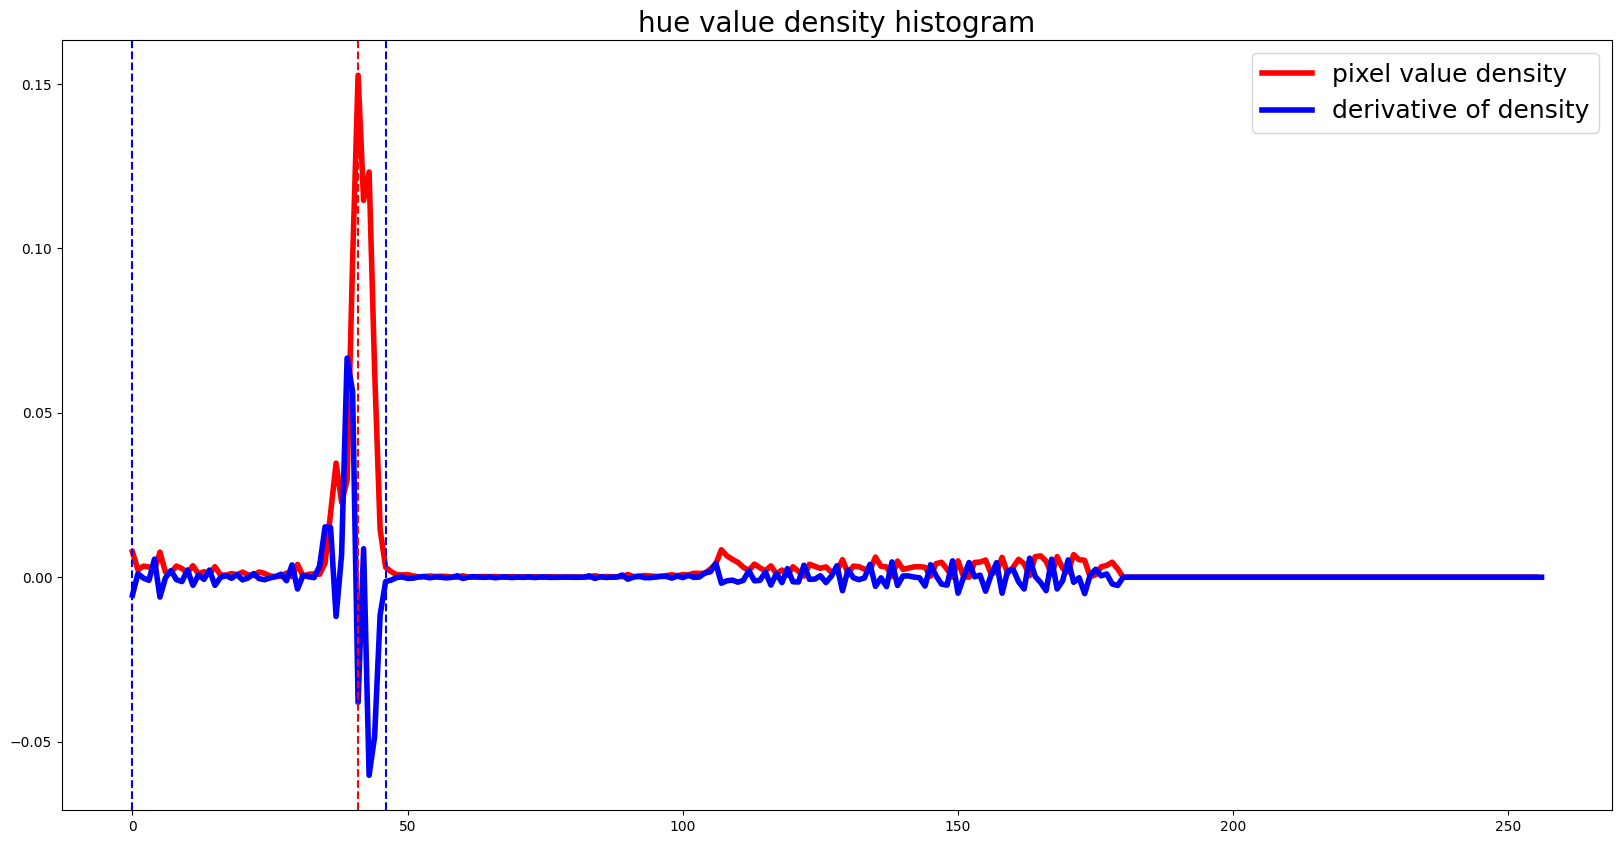

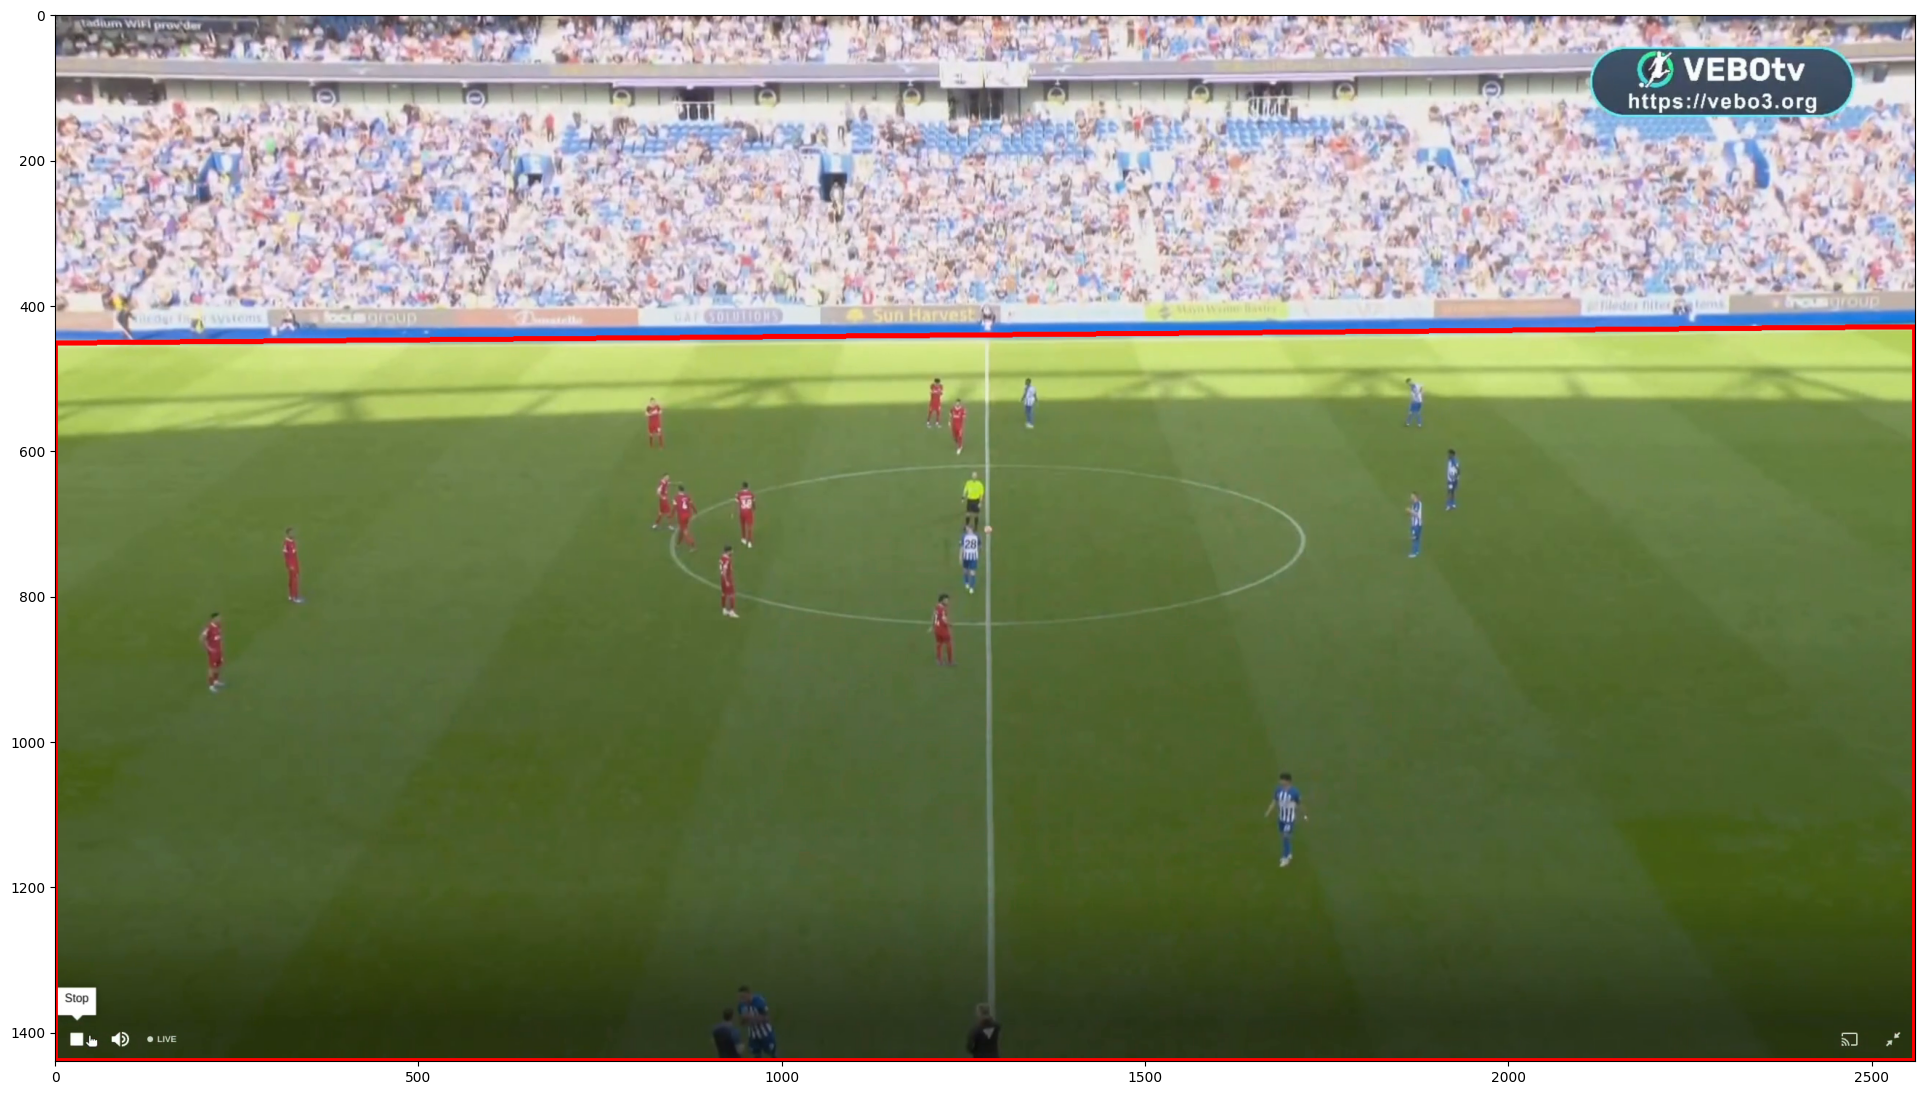

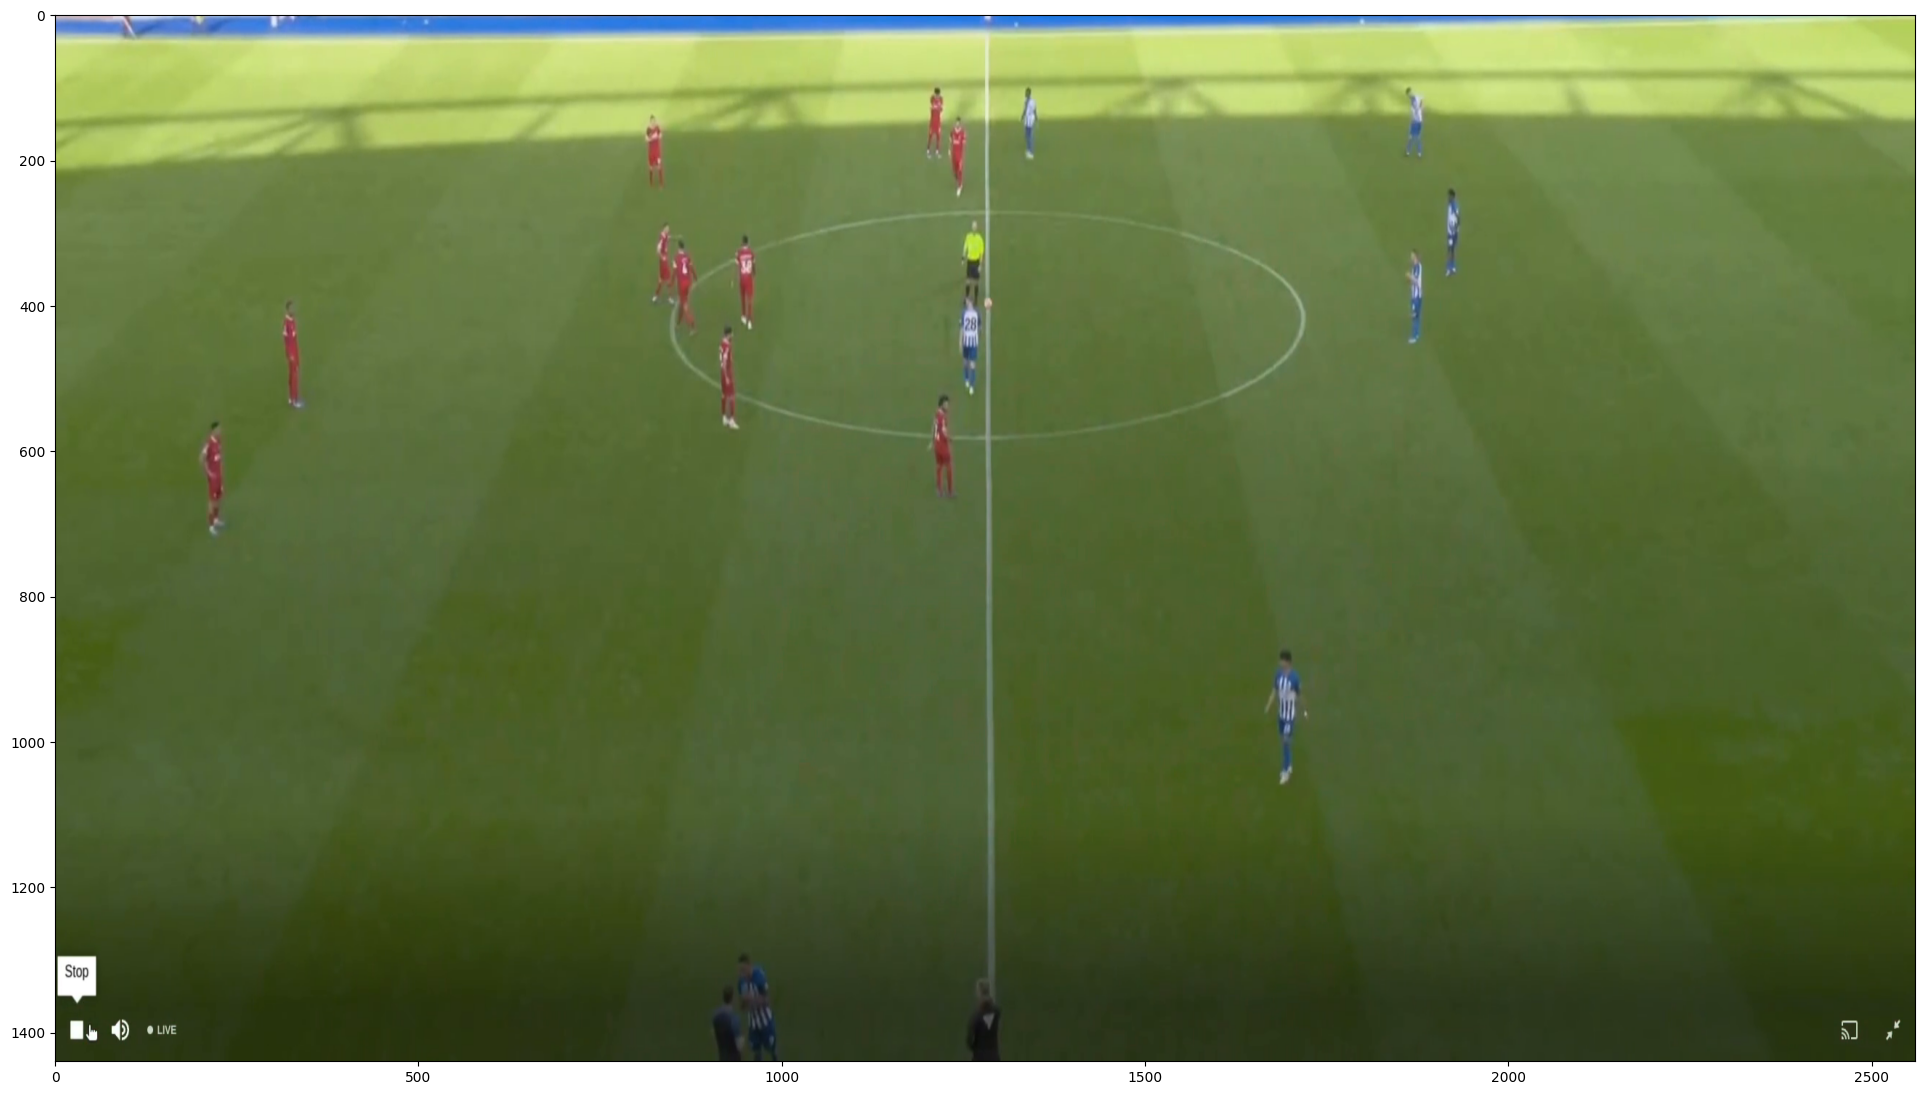

In [3]:
cropped_image = pitch_segment(rgb_image, visualize=True)
orig_h, orig_w, _ = cropped_image.shape

plt.figure()
plt.imshow(cropped_image[:, :, ::-1])

In [9]:
temp = cropped_image.copy()

hsv_image = cv2.cvtColor(temp, cv2.COLOR_BGR2HSV)
lower_green = (30, 40, 40)  # Example lower HSV values for dark green
upper_green = (90, 255, 255)  # Example upper HSV values for dark green

mask = cv2.inRange(hsv_image, lower_green, upper_green)
filtered_dark_green = cv2.bitwise_and(temp, temp, mask=mask)

plt.imshow(filtered_dark_green)

NameError: name 'image' is not defined

##### Canny Edge detection

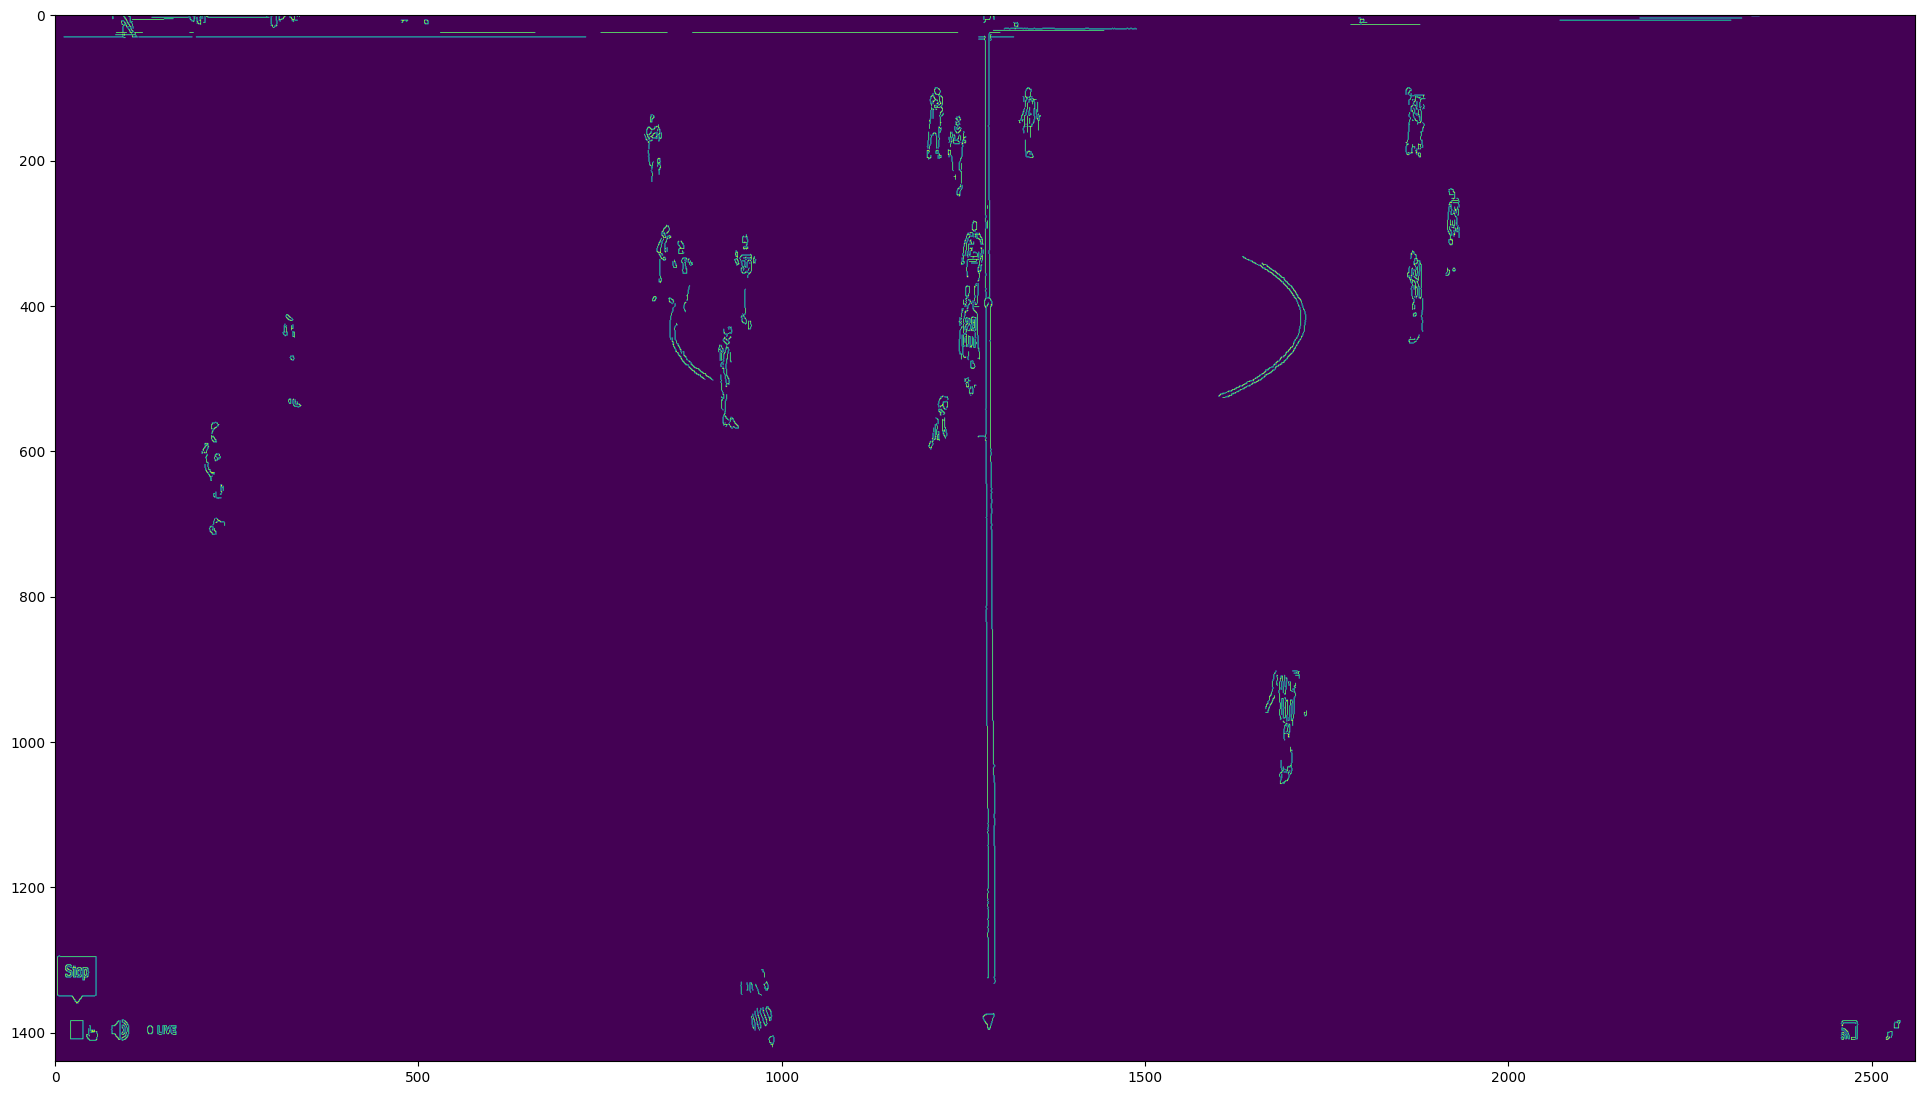

In [5]:
# Canny Edge detection
hsv_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2HSV)
gray_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2GRAY)

sigma = 0.33
v = np.median(gray_image)
lower = int(max(0, (1.0 - sigma) * v))
upper = int(min(255, (1.0 + sigma) * v))
edges = cv2.Canny(cropped_image[:,:, 0], lower, upper)

plt.figure()
plt.imshow(edges)

##### Hough transform

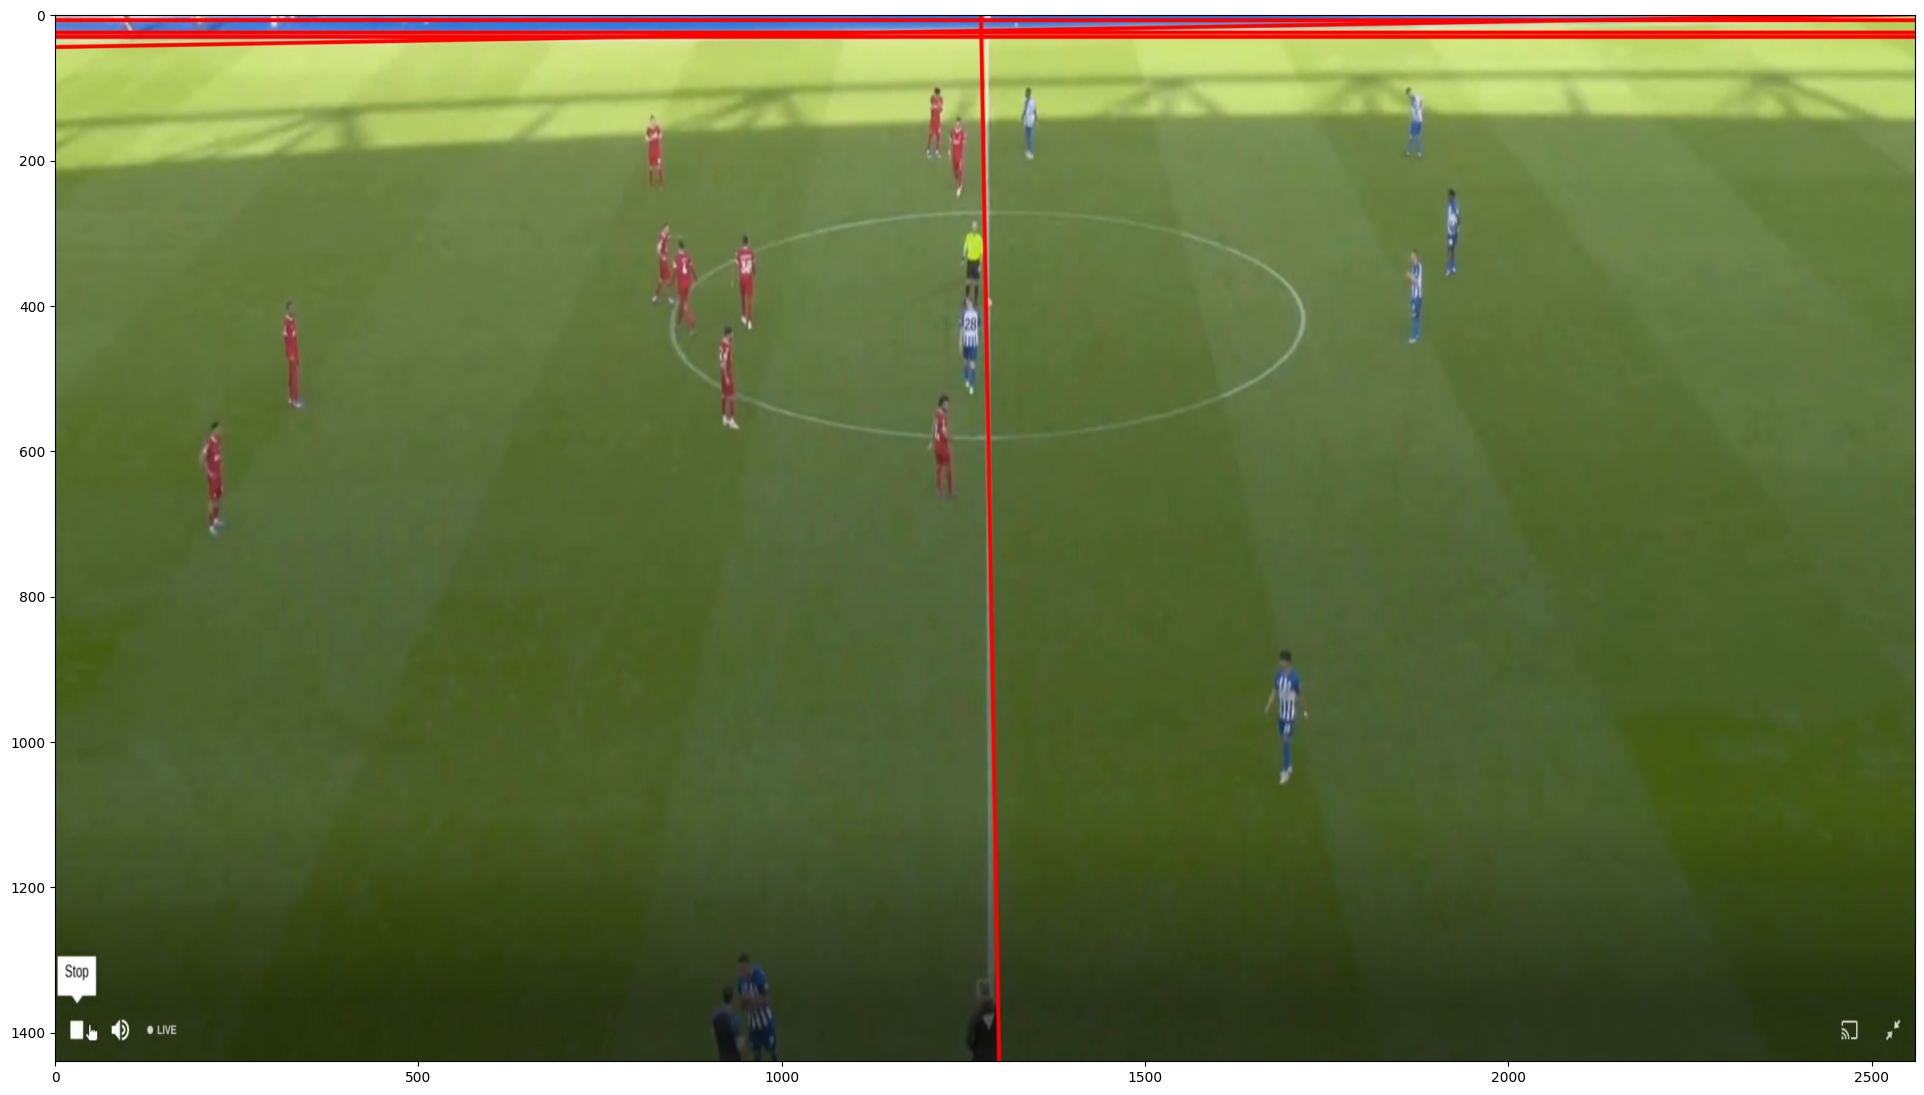

In [6]:
lines = cv2.HoughLines(edges, 1, np.pi / 180, 200)
temp = cropped_image.copy()

if lines is not None:
    for i in range(0, len(lines)):
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
            
        points = hp.line_end_points_on_image(rho, theta, (orig_h, orig_w))
        if len(points) == 2:
            pt1, pt2 = points
            pt2 = (int(x0 - orig_w*(-b)), int(y0 - orig_w*(a)))
            cv2.line(temp, pt1, pt2, (0,0,255), 3, cv2.LINE_AA)

plt.figure()
plt.imshow(temp[:,:,::-1])

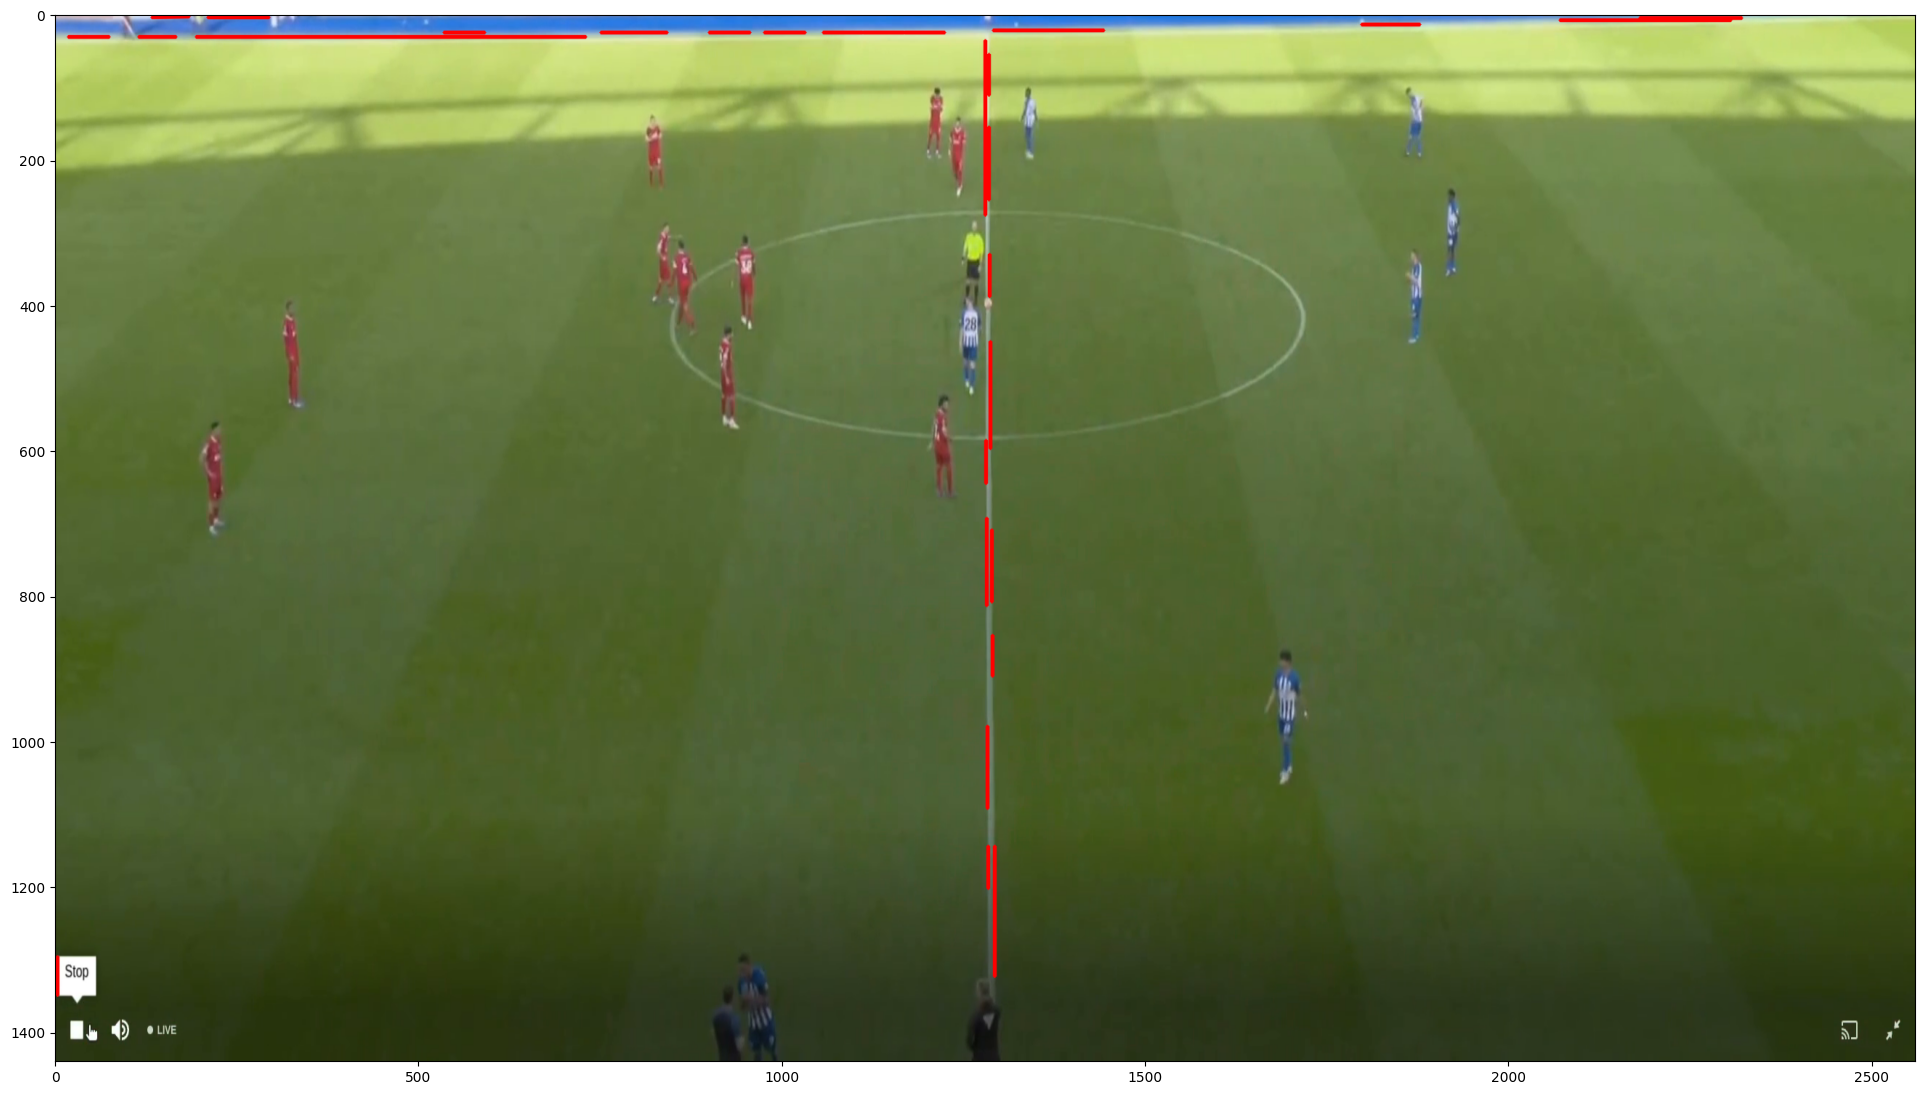

In [7]:
# Propabilistic Hough transform
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 20, 10, 50, 0)
temp = cropped_image.copy()
all_pairs = []
if lines is not None:
    for line in lines:
        cv2.line(temp, (line[0][0], line[0][1]), (line[0][2], line[0][3]), (0,0,255), 3, cv2.LINE_AA)
        all_pairs.append([(line[0][0], line[0][1]), (line[0][2], line[0][3])])
all_pairs = sorted(all_pairs, key = lambda pair: pair[0][1])
plt.figure()
plt.imshow(temp[:,:,::-1])

In [8]:
for point1, point2 in all_pairs:
    if np.absolute(point1[1] - point2[1]) <= 2 and 700 < point1[1] < 800:
        print(point1, point2)